# plot global lagged precursor rates

In [ ]:
import numpy as np
import pandas as pd
import os
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.gridspec import GridSpec
import argparse
import re

In [ ]:
#%% set up path
path = r'/gpfs/work4/0/FWC2/Spatial_dependence/Disease_outbreak/global'
df_all = pd.read_csv(os.path.join(path,'data','public_emdat_custom_request_admin1.csv'))
df_sig_lag = pd.read_csv(os.path.join(path,'output','sig_time_lag',f'first_sig_lag_global_{disease_type}_{hazard_type}.csv'))

#%% shapefile fid, ISO, Country
# df_list = pd.read_csv(os.path.join(path,'data/shapefile/geogunit_0_list.csv'))
# fid_info = pd.read_csv(os.path.join(path,'data','global_country_iso.csv'))
# shpfilename = os.path.join(path,'data/shapefile/geogunit_0.shp')
shpfilename = os.path.join(path,'data/shapefile/ne_10m_admin_0_countries.shp')
shp = gpd.read_file(shpfilename,engine="pyogrio")
# shp = (shp.sort_values(by='ISO')).reset_index(drop=True)
shp = shp.rename(columns={'SOV_A3':'ISO'})
shp = shp[['ISO','geometry']]
# shp["geometry"] = shp.geometry.simplify(tolerance=0.1, preserve_topology=True)

In [5]:
# make a global dataset of precursor rates
# hazard_type_all = ['Climatological', 'Geophysical', 'Hydrological', 'Meteorological']
hazard_type = 'Flood'
disease_type = 'waterborne'
res = pd.read_csv(os.path.join(path, 'output', 'global', f'res_aggregated_rates_global_{hazard_type}_{disease_type}.csv'))
# merge shapefile with precursor rates
df = shp.merge(res,how='left',on='ISO')

In [5]:
# detect sig columns and sort by lag number
sig_cols =res.columns[np.arange(3,41,3)]

# boolean DataFrame where True means sig==1
sig_bool = (res[sig_cols] == 1)

# find column name of first True; set NaN where none True
first_col = sig_bool.idxmax(axis=1)
first_col = first_col.where(sig_bool.any(axis=1), other=np.nan)
res['first_sig_lag'] = first_col.str.extract(r"(\d+)").astype(float)+1
df = shp.merge(res,how='left',on='ISO')

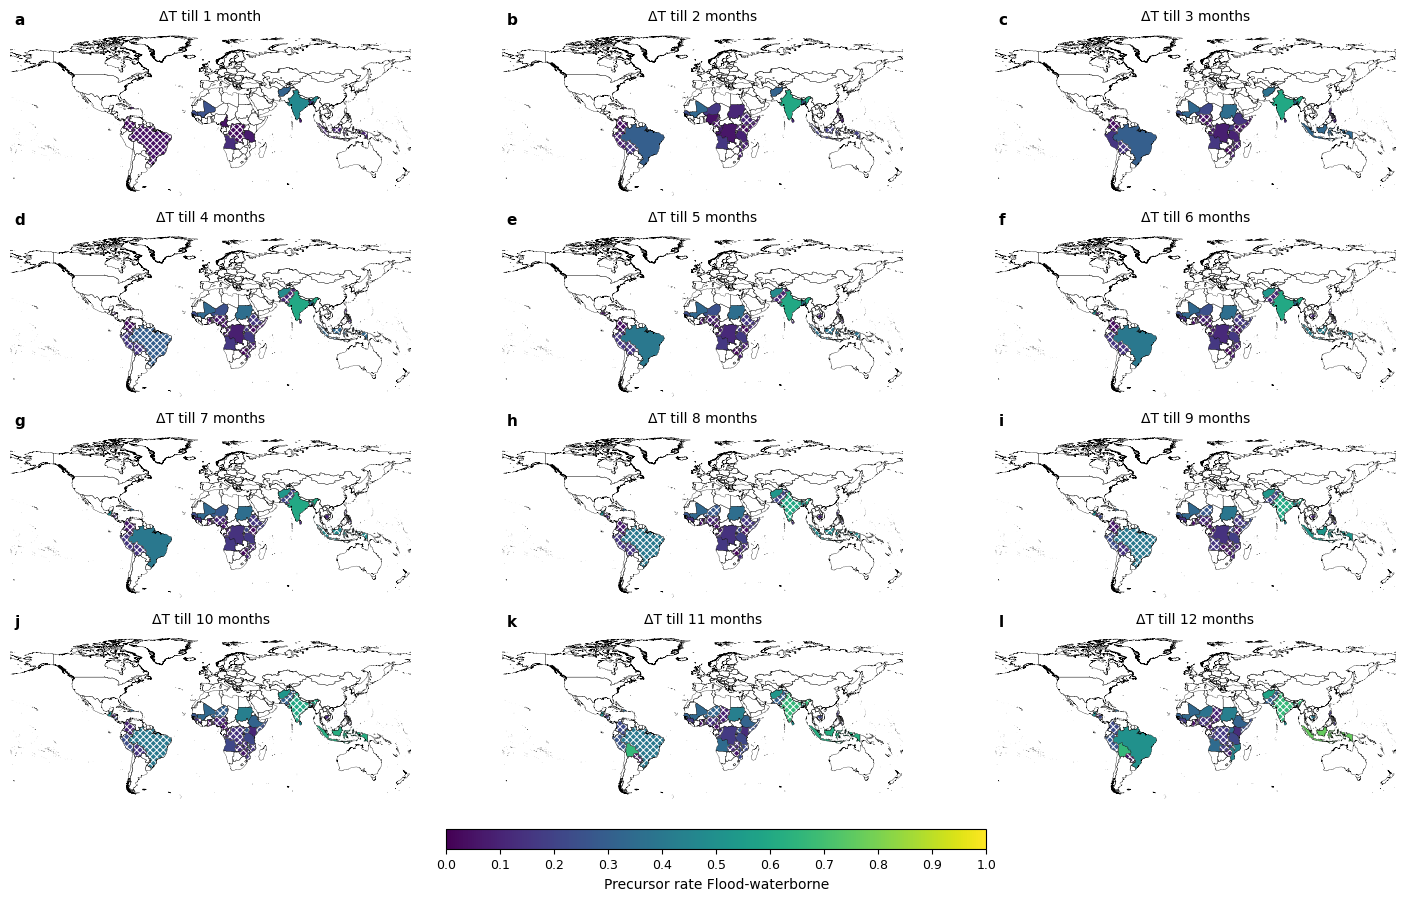

In [6]:
# plotting the global precursor rates for each lag month
delT_all = np.arange(12)
# Create figure with 12 subplots (3 rows x 4 columns)
fig = plt.figure(figsize=(18, 10))
gs = GridSpec(4, 3, figure=fig)
crg = ccrs.PlateCarree()
plt.rcParams.update({'font.size': 9})
plt.rcParams['hatch.linewidth'] = 0.7
cmap = mpl.colormaps.get_cmap("viridis").copy()
# cmap = mpl.colormaps.get_cmap("YlOrRd").copy()
norm = mpl.colors.Normalize(vmin=0, vmax=1)
# bins = np.arange(0, 1.1, 0.1)
# norm = mpl.colors.BoundaryNorm(bins, cmap.N)
panel = ['a','b','c','d','e','f','g','h','i','j','k','l']

for i, delT in enumerate(delT_all):
    ax = fig.add_subplot(gs[i // 3, i % 3], projection=crg)
    df[f"t{delT}"] = df[f"t{delT}"].astype(float)

    t_col = f"t{delT}"
    sig_col = f"sig{delT}_95"

    mask_pos = df[t_col] > 0
    mask_hatch = mask_pos & (df[sig_col] == 0)
    mask_sig = mask_pos & (df[sig_col] == 1)
    mask_nan = (df[t_col].isna()) | (df[t_col] == 0)
    if mask_pos.any():
        df[mask_pos].plot(
            ax=ax, column=t_col, cmap=cmap, vmin=0, vmax=1,
            linewidth=0.2, edgecolor='k'
        )

    if mask_hatch.any():
        # Draw hatches in gainsboro
        df[mask_hatch].plot(
            ax=ax, color="none", edgecolor="white",
            linewidth=0.2, hatch='xxxxx'
        )
        # Overlay a black border for the polygon edges
        # (use .boundary to draw only the outlines)
        df[mask_hatch].boundary.plot(ax=ax, color="k", linewidth=0.2)
        
    # if mask_sig.any():
    #     df[mask_sig].boundary.plot(
    #         ax=ax, color="k", linewidth=0.5
    #     )

    if mask_nan.any():
        df[mask_nan].plot(
            ax=ax, color="none", edgecolor="k",
            linewidth=0.2 
        )
    # Add panel label in the upper-left corner (axes fraction coordinates)
    ax.text(0.01, 1.1, panel[i], transform=ax.transAxes, fontsize=11, fontweight='bold', va='top', ha='left')
    ax.set_extent([-180, 180, -60, 90], crs=crg)

    if i==0:
        ax.set_title(f'ΔT till {delT+1} month', fontsize=10)
    else:
        ax.set_title(f'ΔT till {delT+1} months', fontsize=10)

    ax.set_axis_off()

# Add ONE shared colorbar
cax = fig.add_axes([0.37, 0.06, 0.3, 0.02])
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(
    sm, cax=cax, orientation='horizontal'
)
cbar.set_label(f'Precursor rate {hazard_type}-{disease_type}', size=10)
cbar.set_ticks(np.linspace(0, 1, 11))

# Save the figure
outputdir = os.path.join(path, 'figures')
plt.savefig(os.path.join(outputdir, f'precursor_{hazard_type}_{disease_type}.png'),
            dpi=450, bbox_inches='tight')

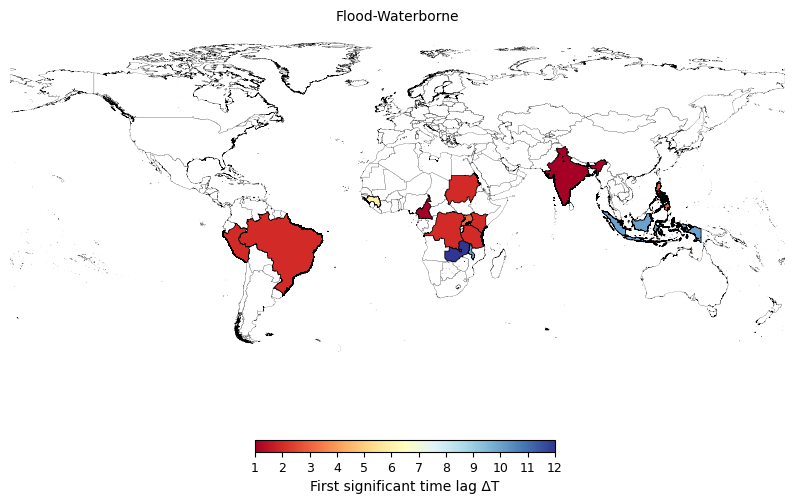

In [27]:
# plotting the first significant lag month for each hazard-disease combination
# Create figure with 12 subplots (3 rows x 4 columns)
fig = plt.figure(figsize=(10, 6))
crg = ccrs.PlateCarree()
plt.rcParams.update({'font.size': 9})
plt.rcParams['hatch.linewidth'] = 1
cmap = mpl.colormaps.get_cmap("RdYlBu").copy()
norm = mpl.colors.Normalize(vmin=1, vmax=12)
# bins = np.arange(0, 1.1, 0.1)
# norm = mpl.colors.BoundaryNorm(bins, cmap.N)
# panel = ['a','b','c','d','e','f','g','h','i','j','k','l']

# for i, delT in enumerate(delT_all):
ax = fig.add_subplot(projection=crg)

# t_col = f"t{delT}"
# sig_col = f"sig{delT}_95"

mask_pos = ~df['first_sig_lag'].isna()
mask_nan = df['first_sig_lag'].isna()

if mask_pos.any():
    df[mask_pos].plot(
        ax=ax, column='first_sig_lag', cmap=cmap, vmin=1, vmax=12,
        linewidth=0.5, edgecolor='k'
    )

if mask_nan.any():
    df[mask_nan].plot(
        ax=ax, color="none", edgecolor="k",
        linewidth=0.1 
    )

# Add panel label in the upper-left corner (axes fraction coordinates)
# ax.text(0.01, 1.05, panel[i], transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')
ax.set_extent([-180, 180, -60, 90], crs=crg)

ax.set_title(f'{hazard_type}-{disease_type}', fontsize=10)


ax.set_axis_off()


# Add ONE shared colorbar
cax = fig.add_axes([0.37, 0.06, 0.3, 0.02])
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(
sm, cax=cax, orientation='horizontal'
)
cbar.set_label(f'First significant time lag ΔT', size=10)
cbar.set_ticks(np.linspace(1, 12, 12))

# Save the figure
# outputdir = os.path.join(path, 'figures')
# plt.savefig(os.path.join(outputdir, f'precursor_{hazard_type}_{disease_type}.png'),
#             dpi=600, bbox_inches='tight')